# Анализ и обработка данных на примере задачи оттока клиентов банка с применением логистической модели

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, log_loss, confusion_matrix, roc_curve,
    precision_recall_curve, average_precision_score,
    classification_report
)
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('./botswana_bank_customer_churn.csv')
df.head()

,RowNumber,CustomerId,Surname,First Name,Date of Birth,Gender,Marital Status,Number of Dependents,Occupation,Income,...,Preferred Communication Channel,Credit Score,Credit History Length,Outstanding Loans,Churn Flag,Churn Reason,Churn Date,Balance,NumOfProducts,NumComplaints
0,1,83ef0b54-35f6-4f84-af58-5653ac0c0dc4,Smith,Troy,1987-08-29,Male,Divorced,3,Information systems manager,77710.14,...,Phone,397,24,41959.74,0,NaN,NaN,211359.05,1,0
1,2,009f115a-e5ca-4cf4-97d6-530140545e4e,Sullivan,Katrina,2000-02-07,Female,Married,1,Charity fundraiser,58209.87,...,Email,665,10,8916.67,0,NaN,NaN,30624.76,4,1
2,3,66309fd3-5009-44d3-a3f7-1657c869d573,Fuller,Henry,1954-02-03,Female,Single,1,Television production assistant,9794.01,...,Email,715,21,43270.54,0,NaN,NaN,111956.61,2,6
3,4,b02a30df-1a5f-4087-8075-2a35432da641,Young,Antonio,1991-01-15,Female,Divorced,5,Agricultural engineer,15088.98,...,Phone,747,17,17887.65,0,NaN,NaN,201187.61,1,0
4,5,0d932e5b-bb3a-4104-8c83-f84270f7f2ea,Andersen,John,1992-04-08,Female,Divorced,2,"Teacher, early years/pre",60726.56,...,Email,549,25,32686.84,0,NaN,NaN,60391.24,5,6


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115640 entries, 0 to 115639
Data columns (total 25 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   RowNumber                        115640 non-null  int64  
 1   CustomerId                       115640 non-null  str    
 2   Surname                          115640 non-null  str    
 3   First Name                       115640 non-null  str    
 4   Date of Birth                    115640 non-null  str    
 5   Gender                           115640 non-null  str    
 6   Marital Status                   115640 non-null  str    
 7   Number of Dependents             115640 non-null  int64  
 8   Occupation                       115640 non-null  str    
 9   Income                           115640 non-null  float64
 10  Education Level                  115640 non-null  str    
 11  Address                          115640 non-null  str    
 12  Contact Infor

In [4]:
df.isnull().sum()

RowNumber                               0
CustomerId                              0
Surname                                 0
First Name                              0
Date of Birth                           0
Gender                                  0
Marital Status                          0
Number of Dependents                    0
Occupation                              0
Income                                  0
Education Level                         0
Address                                 0
Contact Information                     0
Customer Tenure                         0
Customer Segment                        0
Preferred Communication Channel         0
Credit Score                            0
Credit History Length                   0
Outstanding Loans                       0
Churn Flag                              0
Churn Reason                       101546
Churn Date                         101546
Balance                                 0
NumOfProducts                     

In [5]:
df.describe()

,RowNumber,Number of Dependents,Income,Customer Tenure,Credit Score,Credit History Length,Outstanding Loans,Churn Flag,Balance,NumOfProducts,NumComplaints
count,115640.000000,115640.000000,115640.000000,115640.000000,115640.000000,115640.000000,115640.000000,115640.000000,115640.000000,115640.000000,115640.000000
mean,57820.500000,2.502923,52641.363046,15.490591,574.299775,15.546602,25502.731792,0.121878,124639.209748,2.999274,4.991724
std,33382.536902,1.707249,27429.756390,8.654217,159.067499,8.654630,14127.859827,0.327147,72210.476638,1.411361,3.159283
min,1.000000,0.000000,5000.960000,1.000000,300.000000,1.000000,1000.430000,0.000000,1.060000,1.000000,0.000000
25%,28910.750000,1.000000,28857.070000,8.000000,436.000000,8.000000,13226.060000,0.000000,61991.915000,2.000000,2.000000
50%,57820.500000,3.000000,52658.110000,15.000000,574.000000,16.000000,25505.285000,0.000000,124505.890000,3.000000,5.000000
75%,86730.250000,4.000000,76364.157500,23.000000,712.000000,23.000000,37742.250000,0.000000,187122.922500,4.000000,8.000000
max,115640.000000,5.000000,99999.510000,30.000000,850.000000,30.000000,49999.690000,1.000000,249998.910000,5.000000,10.000000


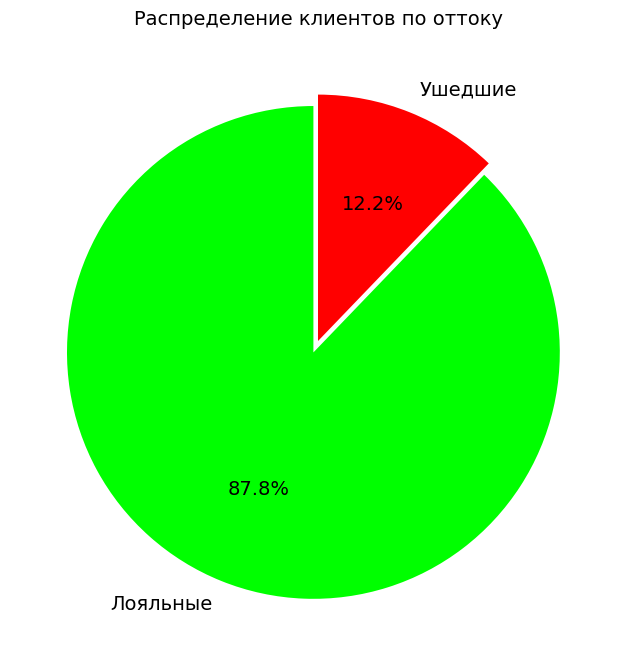

In [6]:
groups = df['Churn Flag'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(groups, labels=['Лояльные', 'Ушедшие'], colors=['lime', 'red'], autopct='%1.1f%%',
        startangle=90, explode=[0.05, 0], textprops={'fontsize': 14})
plt.title('Распределение клиентов по оттоку', fontsize=14)
plt.show()

In [7]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])  # Male=1, Female=0
df['Marital Status'] = le.fit_transform(df['Marital Status']) # Divorced=0, Married=1, Single=2
df['Occupation'] = le.fit_transform(df['Occupation'])
df['Education Level'] = le.fit_transform(df['Education Level'])
df['Customer Segment'] = le.fit_transform(df['Customer Segment']) # SME=0, Corporate=1, Retail=2
df['Preferred Communication Channel'] = le.fit_transform(df['Preferred Communication Channel']) # Email=0, Phone=1
df.head()

,RowNumber,CustomerId,Surname,First Name,Date of Birth,Gender,Marital Status,Number of Dependents,Occupation,Income,...,Preferred Communication Channel,Credit Score,Credit History Length,Outstanding Loans,Churn Flag,Churn Reason,Churn Date,Balance,NumOfProducts,NumComplaints
0,1,83ef0b54-35f6-4f84-af58-5653ac0c0dc4,Smith,Troy,1987-08-29,1,0,3,318,77710.14,...,1,397,24,41959.74,0,NaN,NaN,211359.05,1,0
1,2,009f115a-e5ca-4cf4-97d6-530140545e4e,Sullivan,Katrina,2000-02-07,0,1,1,84,58209.87,...,0,665,10,8916.67,0,NaN,NaN,30624.76,4,1
2,3,66309fd3-5009-44d3-a3f7-1657c869d573,Fuller,Henry,1954-02-03,0,2,1,597,9794.01,...,0,715,21,43270.54,0,NaN,NaN,111956.61,2,6
3,4,b02a30df-1a5f-4087-8075-2a35432da641,Young,Antonio,1991-01-15,0,0,5,26,15088.98,...,1,747,17,17887.65,0,NaN,NaN,201187.61,1,0
4,5,0d932e5b-bb3a-4104-8c83-f84270f7f2ea,Andersen,John,1992-04-08,0,0,2,585,60726.56,...,0,549,25,32686.84,0,NaN,NaN,60391.24,5,6


In [8]:
data = df.drop(['RowNumber', 'CustomerId', 'Surname', 'First Name', 'Date of Birth', 'Address', 'Contact Information', 'Churn Reason', 'Churn Date'], axis=1)

In [9]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 115640 entries, 0 to 115639
Data columns (total 16 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Gender                           115640 non-null  int64  
 1   Marital Status                   115640 non-null  int64  
 2   Number of Dependents             115640 non-null  int64  
 3   Occupation                       115640 non-null  int64  
 4   Income                           115640 non-null  float64
 5   Education Level                  115640 non-null  int64  
 6   Customer Tenure                  115640 non-null  int64  
 7   Customer Segment                 115640 non-null  int64  
 8   Preferred Communication Channel  115640 non-null  int64  
 9   Credit Score                     115640 non-null  int64  
 10  Credit History Length            115640 non-null  int64  
 11  Outstanding Loans                115640 non-null  float64
 12  Churn Flag   

In [10]:
X = data.drop('Churn Flag', axis=1)
y = data['Churn Flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
model = LogisticRegression(
    C=100,
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    max_iter=1000,
    random_state=42, 
    verbose=2, 
    n_jobs=1
)

model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",100
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

In [13]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)
log_loss = log_loss(y_test, y_proba)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"Логарифмическая функция потерь: {log_loss:.4f}")

Accuracy: 0.9983
Precision: 0.9860
Recall: 1.0000
F1: 0.9930
ROC-AUC: 1.0000
PR-AUC: 1.0000
Логарифмическая функция потерь: 0.0036


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20309
           1       0.99      1.00      0.99      2819

    accuracy                           1.00     23128
   macro avg       0.99      1.00      1.00     23128
weighted avg       1.00      1.00      1.00     23128



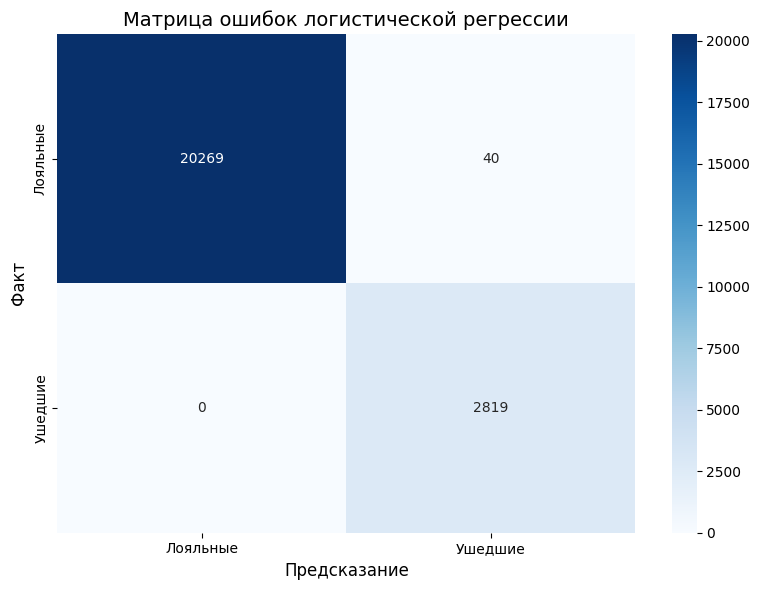

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Лояльные', 'Ушедшие'],
            yticklabels=['Лояльные', 'Ушедшие'])
plt.title("Матрица ошибок логистической регрессии", fontsize=14)
plt.xlabel('Предсказание', fontsize=12)
plt.ylabel('Факт', fontsize=12)
plt.tight_layout()
plt.show()

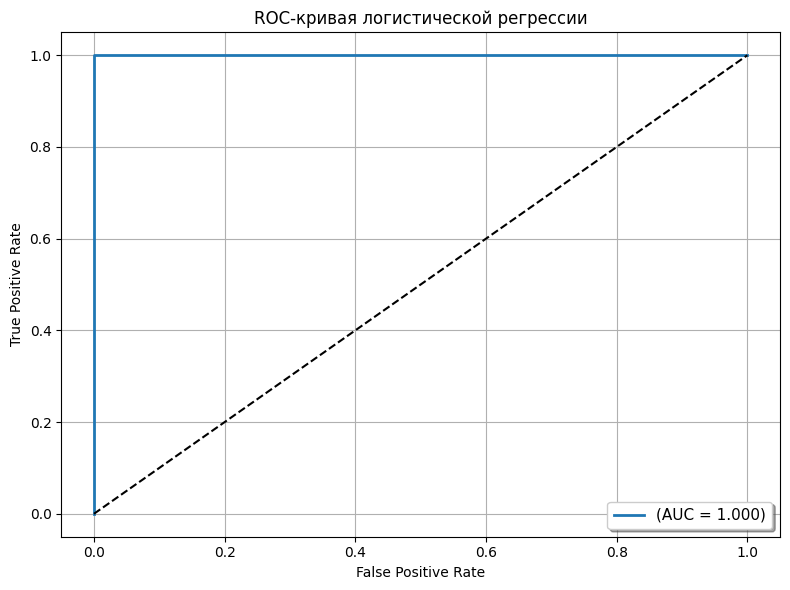

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'(AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC-кривая логистической регрессии")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right', fontsize=11, frameon=True, shadow=True)
plt.grid(True)
plt.tight_layout()
plt.show()

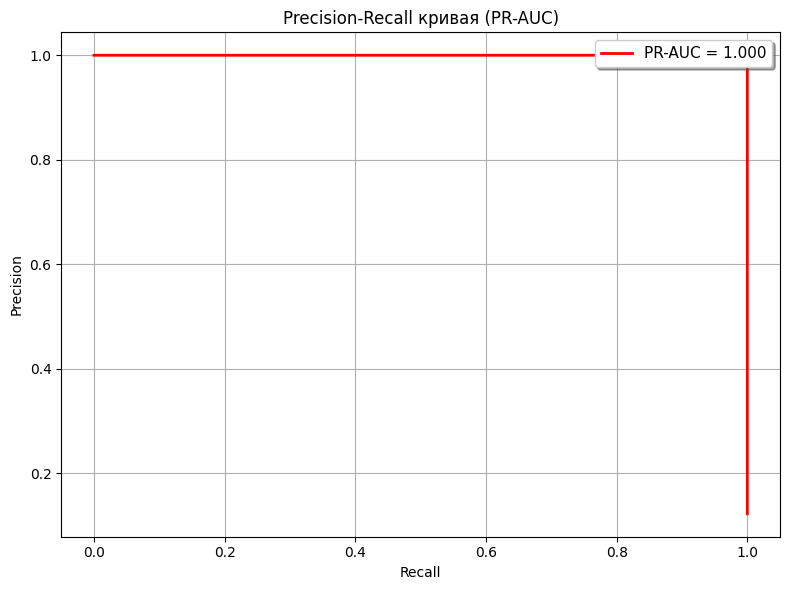

In [17]:
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, label=f'PR-AUC = {pr_auc:.3f}', linewidth=2, color='red')
plt.title("Precision-Recall кривая (PR-AUC)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
plt.grid(True)
plt.tight_layout()
plt.show()


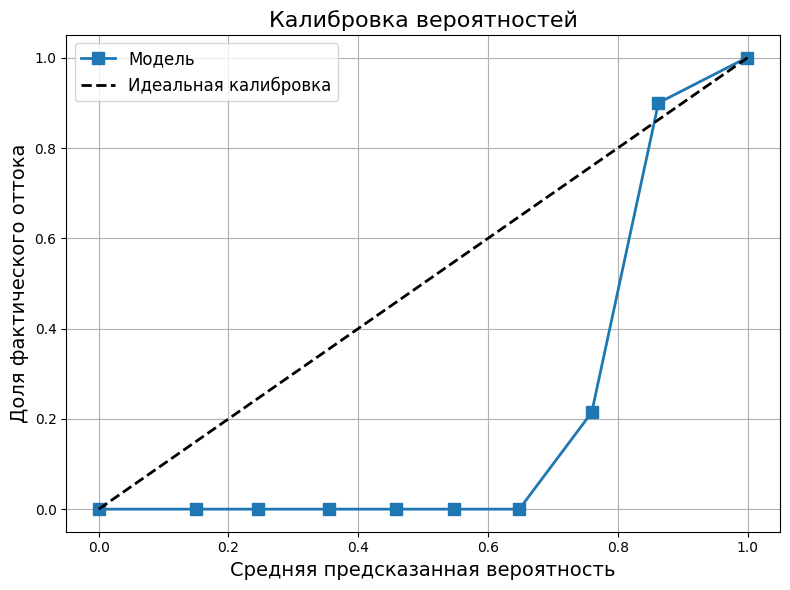

In [18]:
plt.figure(figsize=(8, 6))
prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
plt.plot(prob_pred, prob_true, 's-', label='Модель',
         linewidth=2, markersize=8)
plt.plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка',
         linewidth=2)
plt.title('Калибровка вероятностей', fontsize=16)
plt.xlabel('Средняя предсказанная вероятность', fontsize=14)
plt.ylabel('Доля фактического оттока', fontsize=14)
plt.legend(loc='best', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

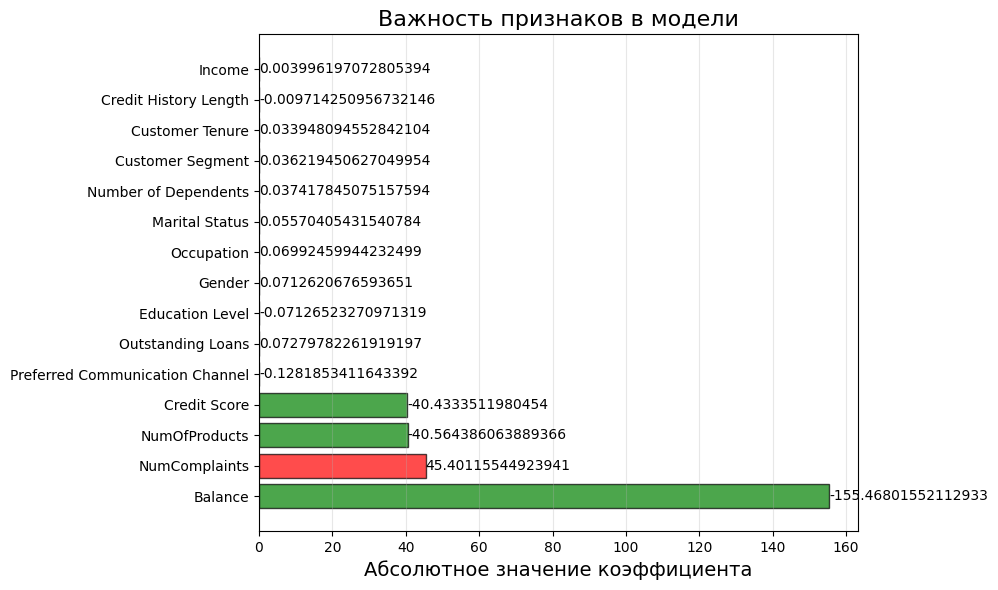

In [19]:
feature_names = X.columns.tolist()
coefficients = pd.DataFrame({
    'Признак': feature_names,
    'Коэффициент': model.coef_[0],
    'Абсолютное_значение': np.abs(model.coef_[0])
}).sort_values('Абсолютное_значение', ascending=False)

plt.figure(figsize=(10, 6))
colors = ['red' if coef > 0 else 'green' for coef in coefficients['Коэффициент']]
bars = plt.barh(coefficients['Признак'], coefficients['Абсолютное_значение'],
                color=colors, edgecolor='black', alpha=0.7)
plt.title('Важность признаков в модели', fontsize=16)
plt.xlabel('Абсолютное значение коэффициента', fontsize=14)
plt.grid(True, axis='x', alpha=0.3)

for bar, coef in zip(bars, coefficients['Коэффициент']):
    width = bar.get_width()
    plt.text(width + 0.005, bar.get_y() + bar.get_height()/2,
             f'{coef}', va='center', fontsize=10)

plt.tight_layout()
plt.show()